# Tải thư viện

In [ ]:
import pandas as pd
import kagglehub
import os
import re
import emoji
import matplotlib.pyplot as plt

# Tải dữ liệu

In [ ]:
path = kagglehub.dataset_download(
    "dduongdev/shopee-vietnamese-product-reviews-sentiment"
)
file_path = os.path.join(path, "shopee_reviews_dataset.jsonl")

df = pd.read_json(file_path, lines=True)

print(df.head())

100%|██████████| 861k/861k [00:00<00:00, 69.2MB/s]

Extracting files...


            id                                             review  rating  \
0  74263765409  Hương vị:thom  Chắc do bên giao hàng bị vỡ mấy...       3   
1  11104151002  Hương thơm:nhẹ nhàng Lợi ích:phục hồi cấp ẩm M...       5   
2  15888299382  Chất lượng sản phẩm:ok Đúng với mô tả:đúng  Lầ...       5   
3  81030214453  Độ tuổi sử dụng:em bes Chất lượng sản phẩm:tot...       5   
4  88484377297  Hương vị:Mix vị, Tím  Mình mua 64 gói (32 gói ...       1   

      label  
0  negative  
1  positive  
2  positive  
3  positive  
4  negative  


In [ ]:
df = df[['review', 'label']]

In [ ]:
df['label'].unique()

array(['negative', 'positive'], dtype=object)

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
df['review'][35:40]

,review
35,"Kinh nghiệm sử dụng:ok Hương thơm:k mùi Mẹo:k cos Giao hàng nhanh đóng gói đầy đủ cẩn thận, chất lượng ọk"
36,"t phải mua cả mấy chục chai tẩy trang này xài rồi, mua cả cho t và người thân ấy. Ai cũng ưng tẩy siêu sạch dù là mascara, sale siêu rẻ chỉ tầm 150k 1 chai ý mà bth bên ngoài bán tận hơn 200 lận😻 tôi yêu loreal"
37,ko nhận đc khuyến mại
38,"Giao hàng nhanh, chất lượng sản phẩm ổn, mùi thơm dễ chịu không kích ứng da"
39,"Độ tuổi sử dụng:1t Bao bì/Mẫu mã:bt Chất lượng sản phẩm:bt Lần nào mua 2 lon thì sẽ có 1 lon bị móp trong khi thùng đóng rất chắc chắn, có bọc xốp chống sốc chắc chắn chứng to sữa đã bị móp từ trước rồi mới giao cho khách nhé"


In [ ]:
df.shape

(9599, 2)

# Làm sạch dữ liệu




## Chuyển thành chữ thường (lower case)

In [ ]:
df['review']=df['review'].str.lower()

## Chuẩn hóa kí tự lặp

In [ ]:
def normalize_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

In [ ]:
df['review'] = df['review'].apply(normalize_repeated_chars)

## Xóa emoji

In [ ]:
def remove_emoji_text(text):
    text = emoji.demojize(text)
    text = re.sub(r':\w+:', '', text)  # xóa :emoji_name:
    return text

In [ ]:
df['review'] = df['review'].apply(remove_emoji_text)

## Xóa ký tự rác

In [ ]:
def clean_text(text):
    text = re.sub(
        r"[^a-zA-Z0-9àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ\s\.\,\!\?\:\;]",
        " ",
        text
    )
    return text

In [ ]:
df['review'] = df['review'].apply(clean_text)

## Chuẩn hóa khoảng trắng

In [ ]:
df['review'] = df['review'].astype(str).apply(
    lambda text: re.sub(r'\s+', ' ', text).strip()
)

## Chuẩn hóa cột mục tiêu

In [ ]:
df['label'].unique()

array(['negative', 'positive'], dtype=object)

In [ ]:
df['label'] = (df['label'] == 'positive').astype(int)

In [ ]:
df['label'].unique()

array([0, 1])

# Phân phối biến mục

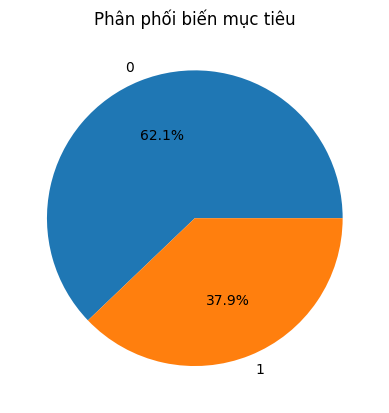

In [ ]:
# Đếm số lượng từng label
counts = df['label'].value_counts()

# Vẽ pie chart
plt.figure()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title('Phân phối biến mục tiêu')
plt.show()